# Phase 4. Cross-Level Agentic Vulnerability Diagnostic
**SA Beverages, Savories diversification**

Dataset is my two debate transcripts, the autonomous board (Phase 2) and the human-led team
cascade (Phase 3), in the labelled Excel. Goal is to measure how the two behave differently when
strategic pushback is suppressed, and tie each difference to a named vulnerability for Phase 5.

Methods grouped the course way. Dictionaries (VADER sentiment plus my own word lists), topic
modeling (LDA, NMF as a check), embeddings (cosine similarity). Both debates ran on Claude Opus 5
(High). My Phase 3 Product Head turns are human-written.

### Setup
Install the libraries. On Colab this takes a few seconds.

In [ ]:
%pip -q install vaderSentiment sentence-transformers scikit-learn matplotlib openpyxl pandas

In [2]:
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import NMF, LatentDirichletAllocation

NAVY="#1F3864"; TEAL="#2E75B6"; ORANGE="#C55A11"; GREY="#808080"
plt.rcParams.update({"font.size":11,"axes.edgecolor":"#cccccc"})

### Step 1. Load the transcripts
Read the labelled Excel. If it is not in the folder (fresh Colab session), upload it.

In [3]:
FILE = "SA_Beverages_Debate_Dataset.xlsx"
try:
    df = pd.read_excel(FILE, sheet_name="Transcripts")
except FileNotFoundError:
    from google.colab import files
    up = files.upload()
    FILE = list(up.keys())[0]
    df = pd.read_excel(FILE, sheet_name="Transcripts")

df = df[["debate_level","round","turn_order","speaker_role","archetype","turn_note","text"]].dropna(subset=["text"])
df["text"] = df["text"].astype(str)

P2 = "Top-Management (Phase 2)"      # the adversarial board
P3 = "Middle-Management (Phase 3)"   # the pushback-suppressed team
LEADER = {P2:"CEO", P3:"Product Head"}
df["leader"] = df.apply(lambda r: r["speaker_role"] == LEADER[r["debate_level"]], axis=1)
print(df.shape, "turns loaded")
df.head(3)

(33, 8) turns loaded


,debate_level,round,turn_order,speaker_role,archetype,turn_note,text,leader
0,Top-Management (Phase 2),1,1,CEO,The Visionary Balancer,Opening,"Colleagues, read the curve. Twenty-five percen...",True
1,Top-Management (Phase 2),1,2,CMO,The Brand Custodian,NaN,"With respect, CEO, the shopper doesn't read ou...",False
2,Top-Management (Phase 2),1,3,CFO,The Profit Sentinel,NaN,"Numbers, please. Our core earns twenty-three p...",False


### Step 2. Preprocessing (deliberate choice)
Keep text raw for sentiment, because VADER uses caps, punctuation and negation (like "not
aligned"). Lowercase and drop stop words for the topic and embedding steps. No stemming or
lemmatising, since that merges distinct words and can hurt on a small dataset.

In [4]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
def toks(t): return re.findall(r"[a-z']+", t.lower())
def clean(t): return " ".join(w for w in toks(t) if w not in ENGLISH_STOP_WORDS and len(w) > 2)

df["nwords"] = df["text"].apply(lambda t: len(toks(t)))   # from raw text
df["clean"]  = df["text"].apply(clean)                     # for topic modeling and embeddings
print("avg words per turn:", round(df["nwords"].mean(),1))
df[["speaker_role","clean"]].head(2)

avg words per turn: 94.8


,speaker_role,clean
0,CEO,colleagues read curve percent growth percent s...
1,CMO,respect ceo shopper doesn't read balance sheet...


### Step 3. Sentiment (dictionary method)
VADER scores each turn. I track the challengers (everyone but the leader) round by round. Expect
the board to stay critical and the team to stay agreeable.

In [5]:
sia = SentimentIntensityAnalyzer()
df["sent"] = df["text"].apply(lambda t: sia.polarity_scores(t)["compound"])
ch = df[~df["leader"]]   # challengers only

sent_round = ch.groupby(["debate_level","round"])["sent"].mean().round(3)
print(sent_round)
print("\nChallenger sentiment overall:",
      {d: round(ch[ch.debate_level==d]["sent"].mean(),3) for d in [P2,P3]})

debate_level                 round
Middle-Management (Phase 3)  1        0.691
                             2        0.596
                             3        0.002
Top-Management (Phase 2)     1        0.012
                             2       -0.374
                             3        0.002
Name: sent, dtype: float64

Challenger sentiment overall: {'Top-Management (Phase 2)': np.float64(-0.12), 'Middle-Management (Phase 3)': np.float64(0.43)}


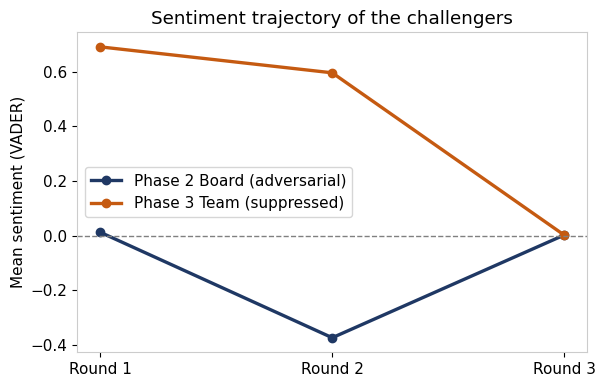

In [6]:
plt.figure(figsize=(6.2,4))
for d,c in [(P2,NAVY),(P3,ORANGE)]:
    ys=[sent_round[(d,r)] for r in [1,2,3]]
    plt.plot([1,2,3],ys,marker="o",lw=2.4,color=c,
             label=("Phase 2 Board (adversarial)" if d==P2 else "Phase 3 Team (suppressed)"))
plt.axhline(0,color=GREY,lw=1,ls="--")
plt.xticks([1,2,3],["Round 1","Round 2","Round 3"]); plt.ylabel("Mean sentiment (VADER)")
plt.title("Sentiment trajectory of the challengers"); plt.legend(); plt.tight_layout(); plt.show()

### Step 4. Challenge vs agreement words (my own dictionaries)
Count resistance words vs agreement words per 100 words. A direct read on how much dissent
survives in each debate.

In [7]:
challenge = set('''but however risk risks unproven concern concerns cannot can't won't not no
disagree veto dilution fail fails failing damage damages blind problem hard aggressive thin gap
kill exposure catastrophic challenge pushback stop broke break'''.split())
agree = set('''aligned align agree agreed yes support supports workable fair clear thank thanks
appreciate appreciated committed commit ready noted understood welcome reassuring trust'''.split())

def rate(sub, lex):
    words = sum(sub["nwords"]); hits = sum(sum(1 for w in toks(t) if w in lex) for t in sub["text"])
    return round(100*hits/max(1,words),2)

for d in [P2,P3]:
    sub = ch[ch.debate_level==d]
    print(d, "-> challenge:", rate(sub,challenge), " agreement:", rate(sub,agree))

Top-Management (Phase 2) -> challenge: 4.29  agreement: 0.71
Middle-Management (Phase 3) -> challenge: 3.53  agreement: 1.89


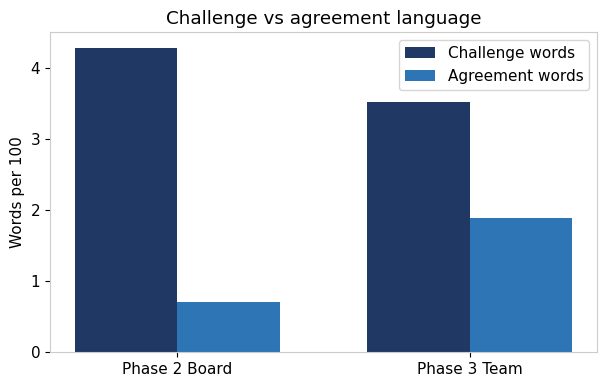

In [8]:
x=np.arange(2); w=0.35
chv=[rate(ch[ch.debate_level==P2],challenge), rate(ch[ch.debate_level==P3],challenge)]
agv=[rate(ch[ch.debate_level==P2],agree),     rate(ch[ch.debate_level==P3],agree)]
plt.figure(figsize=(6.2,4))
plt.bar(x-w/2,chv,w,label="Challenge words",color=NAVY)
plt.bar(x+w/2,agv,w,label="Agreement words",color=TEAL)
plt.xticks(x,["Phase 2 Board","Phase 3 Team"]); plt.ylabel("Words per 100")
plt.title("Challenge vs agreement language"); plt.legend(); plt.tight_layout(); plt.show()

### Step 5. Topic focus (strategy vs execution)
Two keyword lists measure how much each debate talks strategy vs execution. If pushback is banned,
the team should skew hard toward execution.

strategy% , execution% : {'Top-Management (Phase 2)': (34.1, 65.9), 'Middle-Management (Phase 3)': (17.7, 82.3)}


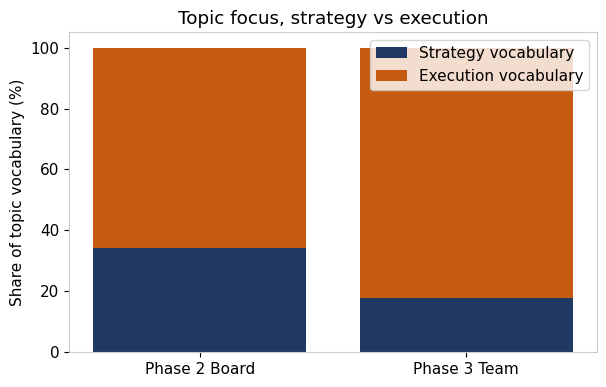

In [9]:
strategy = set('''strategy strategic growth vision direction market markets category diversify
diversification franchise portfolio brand equity valuation existential future decision premium
wedge beachhead'''.split())
execution = set('''budget capex timeline capacity audit audits otif forecast tranche tranches hiring
hire logistics sampling distribution recipe compliance gate gates launch onboarding fssai
traceability slab route routes shelf'''.split())

def share(sub):
    s=sum(sum(1 for w in toks(t) if w in strategy) for t in sub["text"])
    e=sum(sum(1 for w in toks(t) if w in execution) for t in sub["text"])
    tot=s+e; return round(100*s/tot,1), round(100*e/tot,1)
foc={d:share(df[df.debate_level==d]) for d in [P2,P3]}
print("strategy% , execution% :", foc)

st=[foc[P2][0],foc[P3][0]]; ex=[foc[P2][1],foc[P3][1]]
plt.figure(figsize=(6.2,4))
plt.bar(["Phase 2 Board","Phase 3 Team"],st,label="Strategy vocabulary",color=NAVY)
plt.bar(["Phase 2 Board","Phase 3 Team"],ex,bottom=st,label="Execution vocabulary",color=ORANGE)
plt.ylabel("Share of topic vocabulary (%)"); plt.title("Topic focus, strategy vs execution")
plt.legend(); plt.tight_layout(); plt.show()

Bottom-up topic model too. LDA is the main method (the taught one), NMF is a cross-check.
With only ~33 short turns this is indicative, so the keyword measure above is my primary topic
evidence.

In [10]:
# LDA (primary, the taught topic model) on the cleaned text
cv = CountVectorizer(stop_words="english", min_df=1)
C = cv.fit_transform(df["clean"]); cterms = np.array(cv.get_feature_names_out())
lda = LatentDirichletAllocation(n_components=4, random_state=1, max_iter=50).fit(C)
print("LDA topics:")
for k,h in enumerate(lda.components_):
    print(f"  Topic {k+1}:", ", ".join(cterms[np.argsort(h)[::-1][:8]]))

# NMF (cross-check) on TF-IDF
tf = TfidfVectorizer(stop_words="english", min_df=1)
X = tf.fit_transform(df["clean"]); terms=np.array(tf.get_feature_names_out())
nmf = NMF(n_components=4, random_state=1, init="nndsvda", max_iter=400).fit(X)
print("\nNMF topics (cross-check):")
for k,h in enumerate(nmf.components_):
    print(f"  Topic {k+1}:", ", ".join(terms[np.argsort(h)[::-1][:8]]))

LDA topics:
  Topic 1: month, ll, formulation, need, trials, consultants, supply, chain
  Topic 2: months, month, launch, percent, repeat, sub, need, eighteen
  Topic 3: repeat, crore, trial, margin, savories, percent, core, snacks
  Topic 4: core, different, line, shelf, snack, fenced, ring, gate

NMF topics (cross-check):
  Topic 1: tranche, month, market, reviews, sampling, repeat, clock, claim
  Topic 2: crore, phase, gets, cto, savories, percent, parent, distinct
  Topic 3: food, formulation, traceability, blind, fssai, test, recipe, months
  Topic 4: core, packers, snack, snacks, festive, routes, distributors, season


### Step 6. Embeddings and similarity
Turn each turn into a vector and compare with cosine similarity. Sentence-transformers if
available, else TF-IDF. Two tests, convergence (are the four voices merging into one) and echo
(are they mirroring the leader).

In [11]:
try:
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer("all-MiniLM-L6-v2")
    EMB = model.encode(df["text"].tolist(), show_progress_bar=False)
    METHOD = "sentence-transformers (all-MiniLM-L6-v2)"
except Exception as e:
    print("Sentence-transformer model unavailable in this runtime, using TF-IDF fallback:", type(e).__name__)
    EMB = TfidfVectorizer(stop_words="english", min_df=1).fit_transform(df["text"]).toarray()
    METHOD = "TF-IDF vectors (fallback)"
SIM = cosine_similarity(EMB)
df = df.reset_index(drop=True)
print("Embedding method:", METHOD)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sentence-transformer model unavailable in this runtime, using TF-IDF fallback: ProxyError
Embedding method: TF-IDF vectors (fallback)


In [12]:
conv={}; echo={}
for d in [P2,P3]:
    for r in [1,2,3]:
        rows = df[(df.debate_level==d)&(df["round"]==r)]
        ch_i = rows[~rows.leader].index.tolist()
        ld_i = rows[rows.leader].index.tolist()
        pairs=[SIM[a,b] for i,a in enumerate(ch_i) for b in ch_i[i+1:]]
        conv[(d,r)] = round(float(np.mean(pairs)),3)
        echo[(d,r)] = round(float(np.mean([SIM[a,ld_i[0]] for a in ch_i])),3) if ld_i else None
print("Convergence among challengers:", conv)
print("Echo toward leader:", echo)

Convergence among challengers: {('Top-Management (Phase 2)', 1): 0.034, ('Top-Management (Phase 2)', 2): 0.059, ('Top-Management (Phase 2)', 3): 0.06, ('Middle-Management (Phase 3)', 1): 0.067, ('Middle-Management (Phase 3)', 2): 0.101, ('Middle-Management (Phase 3)', 3): 0.106}
Echo toward leader: {('Top-Management (Phase 2)', 1): 0.016, ('Top-Management (Phase 2)', 2): 0.071, ('Top-Management (Phase 2)', 3): 0.023, ('Middle-Management (Phase 3)', 1): 0.188, ('Middle-Management (Phase 3)', 2): 0.233, ('Middle-Management (Phase 3)', 3): 0.232}


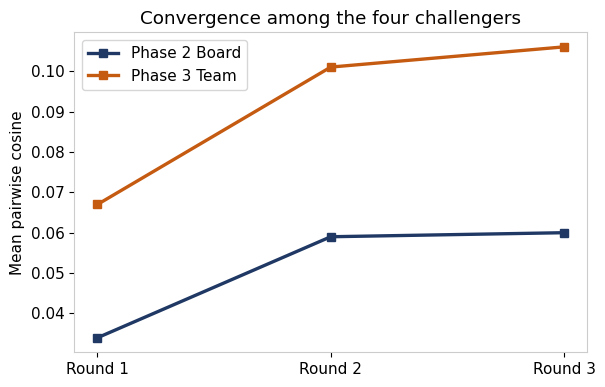

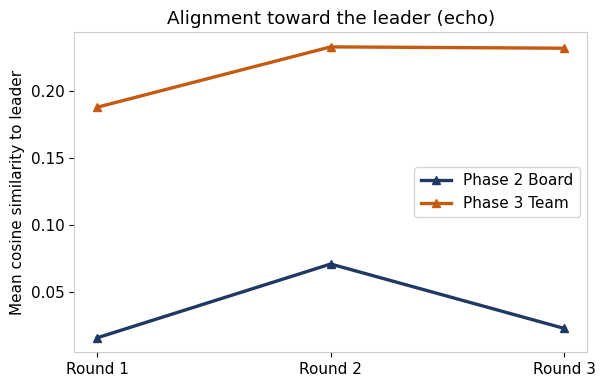

In [13]:
plt.figure(figsize=(6.2,4))
for d,c in [(P2,NAVY),(P3,ORANGE)]:
    plt.plot([1,2,3],[conv[(d,r)] for r in [1,2,3]],marker="s",lw=2.4,color=c,
             label=("Phase 2 Board" if d==P2 else "Phase 3 Team"))
plt.xticks([1,2,3],["Round 1","Round 2","Round 3"]); plt.ylabel("Mean pairwise cosine")
plt.title("Convergence among the four challengers"); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6.2,4))
for d,c in [(P2,NAVY),(P3,ORANGE)]:
    plt.plot([1,2,3],[echo[(d,r)] for r in [1,2,3]],marker="^",lw=2.4,color=c,
             label=("Phase 2 Board" if d==P2 else "Phase 3 Team"))
plt.xticks([1,2,3],["Round 1","Round 2","Round 3"]); plt.ylabel("Mean cosine similarity to leader")
plt.title("Alignment toward the leader (echo)"); plt.legend(); plt.tight_layout(); plt.show()

### Step 7. Findings mapped to vulnerabilities
Pull the numbers together, one named vulnerability per contrast. These feed Phase 5.

In [14]:
sc = pd.read_excel(FILE, sheet_name="Scores")
comp = {d: round(sc[sc.debate_level==d]["score (1-10)"].mean(),2) for d in [P2,P3]}

print("SUMMARY (Board = adversarial, Team = suppressed)")
print("1. Sentiment smoothing / suppressed dissent")
print("   challenger sentiment overall:", {d: round(ch[ch.debate_level==d]['sent'].mean(),2) for d in [P2,P3]})
print("   agreement words/100:", rate(ch[ch.debate_level==P2],agree), "vs", rate(ch[ch.debate_level==P3],agree))
print("2. Sycophancy / echo toward authority")
print("   echo to leader (mean over rounds): Board",
      round(np.mean([echo[(P2,r)] for r in [1,2,3]]),3), " Team",
      round(np.mean([echo[(P3,r)] for r in [1,2,3]]),3))
print("3. Premature convergence / false consensus")
print("   convergence R1->R3: Board", conv[(P2,1)],"->",conv[(P2,3)], " Team", conv[(P3,1)],"->",conv[(P3,3)])
print("4. Topic narrowing / strategic blind spot")
print("   strategy vocab share: Board", foc[P2][0],"%  Team", foc[P3][0],"%")
print("5. Confidence inflation despite less scrutiny")
print("   evaluation composite: Board", comp[P2], " Team", comp[P3])

SUMMARY (Board = adversarial, Team = suppressed)
1. Sentiment smoothing / suppressed dissent
   challenger sentiment overall: {'Top-Management (Phase 2)': np.float64(-0.12), 'Middle-Management (Phase 3)': np.float64(0.43)}
   agreement words/100: 0.71 vs 1.89
2. Sycophancy / echo toward authority
   echo to leader (mean over rounds): Board 0.037  Team 0.218
3. Premature convergence / false consensus
   convergence R1->R3: Board 0.034 -> 0.06  Team 0.067 -> 0.106
4. Topic narrowing / strategic blind spot
   strategy vocab share: Board 34.1 %  Team 17.7 %
5. Confidence inflation despite less scrutiny
   evaluation composite: Board 6.1  Team 7.8
